# Neural Networks for image and tabular data

* Go over basics of NNs in general
* Go over Torch
* Introduce dense layers
* Introdice convolusional layers
* Do the jet-tagger task
* Do the cosmo-classifer task

## How to use this notebook

Welcome! This notebook is your first hands-on encounter with **neural networks**. You'll build models to (1) approximate a simple function, (2) classify points into groups, and (3) tell apart real images of merging galaxies from non-merging ones. Along the way, you'll meet the workhorse library **PyTorch** and the core training loop that powers nearly every modern deep-learning system.

### The three-step rhythm

Throughout the notebook you'll see exercises framed in a very specific way. We want you to practice **thinking, then asking, then reflecting** — in that order. The pattern looks like this:

> 🧠 **Step 1 — Try it yourself.** First, attempt the problem on your own (or with a classmate). It's totally fine to get stuck or write something that doesn't run. Getting stuck is information.
>
> 🤖 **Step 2 — Ask the Agent.** Once you've made an honest attempt, paste your code (or your stuck-point) into an AI agent like Claude, ChatGPT, or Gemini, along with the suggested prompt. Read the response carefully — don't just copy it.
>
> 💬 **Step 3 — Reflect & Discuss.** Compare what you wrote with what the agent suggested. What did you miss? What did the agent get wrong or oversimplify? Be ready to discuss with your group.

This isn't busywork. **The agent is a tutor, not a homework-machine.** If you skip Step 1, you'll learn nothing in Step 2. If you skip Step 3, you'll forget everything by next week. The most important skill you can develop in this tutorial is the ability to *evaluate* what an agent tells you — because agents make mistakes!!!, give plausible-sounding-but-wrong answers, and sometimes miss the physics entirely.

Ready? Let's go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch (for deep learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

# fits
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import simple_norm

# sklearn (for machine learning)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

np.random.seed(42) # For reproducibility, we set the "seed" of our random number generator to a fixed number

# Pytorch

Pytorch is a package used to build neural networks.

In `Pytorch` (refered to as `torch` in code), we can build a model by creating a `Class`, and adding different layer objects within the `__init__` block of the class to define the architecture. The first layer we add is the input layer, and then the last layer we add is our output layer.

You'll also notice that aside from defining the structure of the model, we also define a function called `forward`, which is the function that will be called when we pass data through the model. In this case, we just pass data from one layer to another in a series. In some other cases, you might want to define a more complex `forward` function that does something more complicated with the input data.

Think of the model like a sandwich - it always has bread on the top and the bottom and the contents of the sandwich can vary. 
The "bread" in the model is the input and output layers. 
The input layers need to take the features of our dataset, our x values, and translate them in to a format the rest of the model can use. 
The output layers need to take the next to last layer of the model and transform that output into our "target" variables, the y values we can use to evaluate a loss function. 

Our model sandwich below is pretty boring, an input layer, a single learned transformation, and an output layer.

The dense layers here are simple, they are a matrix of coefficients that modify the input. 
Those coefficients are trainable, they're the parameters of our model. 
(Like how m and b are the parameters of y = m*x+b)

The [`ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html#relu)("Rectified Linear Unit") layers are an "Activation" function, they change the distribution out of the dense output from a linear output to something slightly more non-linear.
They can improve the output of the model by increasing how much non-linearity the model can express. 

# Takeaway 
<p align="center">
  <img src="sanwich.png" 
       alt="PyTorch neural network sandwich" 
       width="900">
</p>

Pytorch has a few main pieces. 

## The Model

Each model is defined as a subclass of [`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module). This is how models can be trained (have a way to update the weights automatically), calculate and apply gradients according to loss functions, and use advanced features like sending parameters to specific devices like cpu and gpu.

A basic model looks like this: 

```python 
import torch.nn as nn

class NN(nn.Module): 
    def __init__(self):
        super().__init__() 
        self.model = ...

    def forward(self, input_data): 
        return self.model(input_data)
```

## Loss Function

[Loss functions in PyTorch](https://docs.pytorch.org/docs/stable/nn.html#loss-functions) measure how different the model prediction is from the true answer.

For example, if the model predicts $\hat{y}$ and the true value is $y$, the loss tells us how “wrong” the prediction is. One of the most common loss functions is the mean squared error (MSE):

$$
\mathcal{L} = |\hat{y} - y|^2
$$

During training, PyTorch uses this loss to compute gradients and update the model parameters. A smaller loss usually means the model is making better predictions.

For large datasets, the loss is usually computed batch by batch and then summarized over the full training process. It generally looks something like this:

```python
import torch.nn.MSELoss as MSELoss
model = NN()
loss_func = MSELoss()
dataset = ...

batch_loss = []
for input_data, target in dataset: # <- iterates across n batches of the dataset
    optimizer.zero_grad() # <- set gradient to its initial condition before computing across a new batch 
    output = model(input_data)
    loss = loss_fn(output, target) # <- use loss.__call__ to get the difference between the expected and predicted
    loss.backward() # <- Compute the gradient from that loss, used in the optimizer

    batch_loss.append(batch_loss.item()) # Only getting the value of the loss, not the gradient, with `.item()`
    
total_batch_loss = sum(batch_loss)/len(batch_loss) # Take the average across the batch to report
```


## Optimizer

The [optimizer](https://docs.pytorch.org/docs/stable/optim.html) is the part of training that updates the model parameters.

Remember that the model has trainable numbers inside it, such as the weights and biases in dense layers. During training, PyTorch first computes the loss, which tells us how wrong the model prediction was. Then, PyTorch computes gradients, which tell us how each parameter should change to make the loss smaller.

The optimizer uses those gradients to update the parameters. In other words, the optimizer is what allows the model to actually learn from its mistakes.

When we create an optimizer, we usually give it two things:

1. the model parameters we want to train, usually `model.parameters()`
2. settings for the optimizer, such as the learning rate `lr`

The learning rate controls how big each update is. A small learning rate means the model changes slowly. A large learning rate means the model changes more quickly, but it can also make training unstable.

It generally, the code looks like this:

```python
from torch.optim import SGD

model = NN()
loss_func = MSELoss()
lr = 0.01 # Some initial condition
optimizer = SGD(
    model.parameters()  # Because model is a torch.nn.Module object, it as the `parameters` function
    lr=lr
)
dataset = ...

for input_data, target in dataset:
    optimizer.zero_grad()
    output = model(input)
    loss = loss_fn(output, target)
    loss.backward()
    optimizer.step() # <- Critical last step, use the backward step of loss to update the model weights

```

# Takeaway 
<p align="center">
  <img src="optimizer.png" 
       alt="PyTorch neural network sandwich" 
       width="900">
</p>


### 🧠 Concept check — before you touch the code

You just read about three things that *every* PyTorch training program contains: a **model**, a **loss function**, and an **optimizer**. These three appear together so often it's worth burning them into memory.

#### Try it yourself — without running any code
Answer in your own words (a sentence each is enough):

1. **Model.** If the model is "the sandwich," what are the "bread" layers doing, and what are the "filling" layers doing?
2. **Loss.** What does the loss do during training? why is it important? can we have different losses for different models?
3. **Optimizer.** What does `optimizer.zero_grad()` do, and *why* must we call it every batch? (Hint: gradients in PyTorch *accumulate* by default.)
4. **Learning rate.** What might go wrong if you pick `lr=10`? What about `lr=0.0000001`?

#### 🤖 Ask the agent
Try this prompt:

> *"Hi Robot! Explain to me, why gradients accumulate in PyTorch by default and why we need `zero_grad()`. Give me a tiny code example showing what happens if I forget to call it."*

#### 💬 Reflect
Do I have a basic understanding all that is behid scenes in a simple model in pytorch?

---

# Part 1 — Regression: teaching a network to learn $y = x^2$

We'll start with the simplest possible "physics-ish" task: given pairs $(x, y)$ that lie on a parabola, can a neural network learn the rule?

This is a **regression** problem — the output is a continuous number, not a category. Compared to the famous "is this a cat or a dog?" classification problems you may have heard of, regression is closer to fitting a curve.

In [2]:
# Generate training and testing data
samples = 2000
train_range = 100
test_range = 200


def func(x):
    return x ** 2


x = np.random.random((samples, 1)) * train_range - (train_range / 2)
y = np.array(list(map(func, x))).reshape(-1, 1)

x_test = np.random.random((int(samples / 2), 1)) * test_range - (test_range / 2)
y_test = np.array(list(map(func, x_test))).reshape(-1, 1)

#### 🧠 Quick sanity check before plotting

Look at the code above and answer:

1. What is the **range** of `x` values in the training set? In the test set?
2. How many training samples are there? How many test samples?
3. The line `np.array(list(map(func, x))).reshape(-1, 1)` is a bit clunky. Can you rewrite it more idiomatically using NumPy's vectorized operations? (Hint: NumPy can square arrays directly.)

#### 🤖 Ask the agent
> *"Here's a snippet that applies a function elementwise using `map` and reshapes the result. Show me a more Pythonic, vectorized way using NumPy, and explain why the vectorized version is faster."*

#### 💬 Reflect
Vectorization isn't just style — for big arrays it can be **100× faster**. Run `%timeit` on both versions if you're curious.

Text(0.5, 0, 'x')

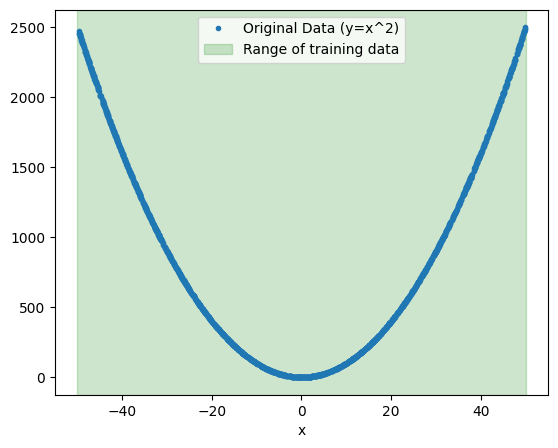

In [3]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(x, y, ".", label="Original Data (y=x^2)")
plt.axvspan(-50, 50, color='green', alpha=0.2, label="Range of training data")
plt.legend()
plt.xlabel('x')

> 👀 **What do you notice?** The shaded green band shows where your *training* data lives. The test data extends well beyond it. Hold this picture in your head — we'll come back to it when we evaluate the trained model.

### 🐛 A teachable bug

The cell below defines our first real PyTorch model. **It contains a small bug** that will raise an error when you run it. We left it in on purpose.

**Before running it:**
1. Read the class carefully. Look at the line `super().__init__(self)`.
2. Compare it to how `super().__init__()` is normally called for a subclass.

**Now run it and read the error message.** Errors in Python often look scary but they tell you exactly where to look.

#### 🤖 Only after you've stared at the error
> *"I got this error when running a PyTorch `nn.Module` subclass: [paste full error]. Here's my class definition: [paste class]. What's wrong, and why is the fix what it is?"*

#### 💬 Reflect
- Did the agent point to the exact line? Did it explain *why* `super().__init__()` should not take `self` as an argument?
- This bug appears in **two more places** later in this notebook (look in the classification section and the CNN section). Once you understand it here, fix it there too.

In [4]:
class SimpleNN(nn.Module): #< - Making a "subclass" of "nn.Module", tells pytorch that this is a neural network
    def __init__(self):
        # super().__init__(self) #< - Calling the "constructor" of the parent class, "nn.Module", does setup that lets us call things like the parameters of the model. 
        super().__init__() # correct answer
        self.input_layer = nn.Linear(1, 10) #< - A linear layer with 1 input and 10 outputs
        self.hidden_layer = nn.Linear(10, 10) #< - A linear layer
        self.relu = nn.ReLU() #< - A non-linear activation function, it does not have weights, so we don't need a different instance for each time we use it. 
        self.output_layer = nn.Linear(10, 1) #< - A linear layer with 10 inputs and 1 output

    def forward(self, x): # <- This is the forward call, which is used when you call the model on some data, e.g. "model(x)"
        # Use this to say how data is passed from layer to layer
        x = self.input_layer(x) 
        x = self.relu(x)
        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

#### 🧠 Count the parameters

The line `summary(SimpleNN(), input_size=(1, 1))` (which uses `torchinfo`) will print a table showing how many trainable parameters the model has. **Before** you run it, predict the number on paper:

- `nn.Linear(1, 10)`: how many weights? How many biases? Total = ?
- `nn.Linear(10, 10)`: how many weights? Biases? Total = ?
- `nn.Linear(10, 1)`: total = ?

In [5]:
summary(SimpleNN(), input_size=(1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [1, 1]                    --
├─Linear: 1-1                            [1, 10]                   20
├─ReLU: 1-2                              [1, 10]                   --
├─Linear: 1-3                            [1, 10]                   110
├─ReLU: 1-4                              [1, 10]                   --
├─Linear: 1-5                            [1, 1]                    11
Total params: 141
Trainable params: 141
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

#### 🤖 Check yourself
> *"In a PyTorch `nn.Linear(in_features, out_features)` layer, how many trainable parameters are there in terms of `in_features` and `out_features`? Show me the formula and a worked example."*

#### 💬 Reflect
You'll often hear people say a model has "10 million parameters" or "70 billion parameters." That number is just the sum of the weights and biases across all layers. Now you know exactly what it means.

In [6]:
# Set up the model, loss function, and optimizer
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# How long we will train the model, how many times to loop through the data
epochs = 100

In [7]:
# Perform train-test-validation split and convert the numpy data into PyTorch tensors

# Split the existing "train" data further into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

# Convert the numpy arrays to PyTorch tensors so that we can use them in our model
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

batch_size = 256
train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)  # We can use the data.TensorDataset object to make the dataset iterable
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

#### 🧠 Why three splits, not two?

You just saw `train_test_split` used to carve out a **validation** set in addition to the existing train/test split. That gives you three sets:

- **Train** — the model sees this and updates its weights from it.
- **Validation** — the model never trains on this, but you check performance here *during* training to decide when to stop / tune hyperparameters.
- **Test** — touched only at the very end, used to report final performance. If you tune anything based on the test set, you've contaminated it.

#### Try it yourself
Suppose a classmate skips the validation set and tunes the learning rate by re-running training and watching test loss. What's the problem with their methodology?

#### 🤖 Ask the agent
> *"Explain the difference between validation and test sets in ML, with an example of a mistake a beginner might make by conflating them."*

#### 💬 Reflect
This is exactly the same intuition as "don't peek at your hold-out data" in experimental physics. Validation = the calibration runs you fiddle with; test = the final blinded analysis.

### 🧠 Read the training loop *slowly*

This is the most important cell in the notebook. Almost every neural network you'll ever train uses a loop that looks like this:

```
for each epoch:
    for each batch in training data:
        zero gradients
        forward pass    →  predictions
        compute loss     →  number
        backward pass    →  gradients
        optimizer step  →  update weights
    evaluate on validation data
```

#### 🤖 After you've matched the lines yourself
> *"Walk me through this PyTorch training loop line by line. For each line, tell me: what does it do mechanically, and which step of gradient descent does it correspond to? [paste cell]"*

#### 💬 Reflect
What is `model.train()` vs `model.eval()` actually doing? (Hint: it matters for layers like Dropout and BatchNorm, which you'll meet in the CNN section.)

In [8]:
for epoch in range(epochs):
    model.train() # Tell the model we're in training mode
    # Training step, iterating over the training data in batches
    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad() # Clear the gradients from the previous step
        outputs = model(batch_x) # Pass the input data through the model to get predictions
        loss = criterion(outputs, batch_y) # Calculate the loss between the predictions and the true values
        loss.backward() # Calculate the gradients of the loss with respect to the model's parameters
        optimizer.step() # Update the model's parameters using the optimizer

    # Validation step
    model.eval() # Tell the model we're in evaluation mode
    with torch.no_grad(): # Disable gradient calculation for validation, as we aren't updating the parameters of the model with the validation data
        val_outputs = model(x_val_tensor) # Pass the validation data through the model to get predictions
        val_loss = criterion(val_outputs, y_val_tensor) # Calculate the loss between the predictions and the true values
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}") # Report the validation loss for this epoch

Epoch 1/100, Training Loss: 1305511.1250, Validation Loss: 1324336.7500
Epoch 2/100, Training Loss: 1072423.5000, Validation Loss: 1323499.3750
Epoch 3/100, Training Loss: 1423399.6250, Validation Loss: 1322667.0000
Epoch 4/100, Training Loss: 1232035.3750, Validation Loss: 1321832.0000
Epoch 5/100, Training Loss: 1160303.5000, Validation Loss: 1320907.5000
Epoch 6/100, Training Loss: 1158688.2500, Validation Loss: 1319879.2500
Epoch 7/100, Training Loss: 1469901.7500, Validation Loss: 1318744.7500
Epoch 8/100, Training Loss: 1440938.3750, Validation Loss: 1317464.6250
Epoch 9/100, Training Loss: 1059715.0000, Validation Loss: 1315905.0000
Epoch 10/100, Training Loss: 1260299.2500, Validation Loss: 1313811.8750
Epoch 11/100, Training Loss: 1283738.3750, Validation Loss: 1311444.7500
Epoch 12/100, Training Loss: 1176141.7500, Validation Loss: 1308842.1250
Epoch 13/100, Training Loss: 1263325.1250, Validation Loss: 1306033.5000
Epoch 14/100, Training Loss: 1462272.8750, Validation Loss: 

In [9]:
# Create some predictions on the test data
model.eval() # Tell the model we're in evaluation mode
with torch.no_grad(): # Disable gradient calculation for testing, as we aren't updating the parameters of
    predictions = model(x_test_tensor) # Pass the test data through the model to get predictions
    test_loss = criterion(predictions, y_test_tensor) # Calculate the loss between the predictions and the true values
print(f"Test Loss: {test_loss.item():.4f}") # Report the test loss

Test Loss: 8562465.0000


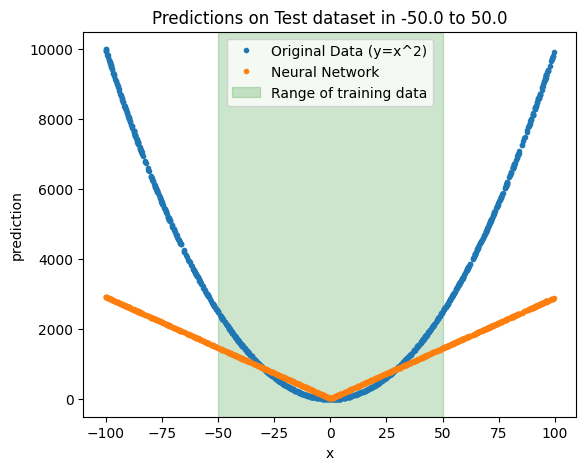

In [10]:
# Plot predictions on test data
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(x_test, y_test, ".", label="Original Data (y=x^2)")
plt.plot(x_test, predictions.numpy(), '.', label="Neural Network")
plt.axvspan(-50, 50, color='green', alpha=0.2, label="Range of training data")
plt.legend()
plt.xlabel('x')
plt.ylabel('prediction')
plt.title('Predictions on Test dataset in {} to {}'.format(-(train_range / 2), (train_range / 2)))
plt.show()

### 💬 The big lesson: look at where the prediction breaks

Look at your plotted predictions carefully. **The neural network should fit beautifully inside the green shaded band** (where it saw training data), but **diverge from the true parabola outside of it**.

This is not a bug. It is the most important lesson in this entire notebook.

> Neural networks **interpolate** well and **extrapolate** terribly. They have no idea that $y = x^2$ is the rule; they only know "the points I saw look like *this*." Outside that range, anything goes.

#### Try it yourself
1. Change `train_range` to `200` (so training data covers the whole test range) and re-run. Does the prediction now match outside the original window?
2. Change `func` to $y = \sin(x)$. Does the network still do well? What about $y = e^x$?
3. Without re-training, what does this tell you about applying ML models to physics data taken under *new* experimental conditions?

#### 🤖 Ask the agent
> *"Why do neural networks generally fail to extrapolate beyond the range of their training data? Give me both an intuitive explanation and a more technical one in terms of the activation functions and architecture."*

#### 💬 Discuss with your group
- Find a recent paper in your field that uses ML. Did the authors check whether their test data lies inside the distribution of their training data?
- A common phrase is "interpolation vs. extrapolation in distribution." What do you think "in distribution" means?

# Using neural networks for classification tasks

## What changes for classification?

So far we've predicted a **number**. Now we'll predict a **category**: which of $K$ classes does an input belong to? In physics this looks like:

- Is this particle track a muon or a pion?
- Is this stellar spectrum from an O-type or B-type star?
- Does this image of a galaxy show a merger or not? *(We'll do this exact task in Part 3!)*

#### Three things change when you move from regression to classification

| Aspect | Regression | Classification |
|---|---|---|
| **Output size** | Usually 1 number | $K$ numbers (one per class) — or 1 probability for binary |
| **Final activation** | Often nothing (or identity) | Softmax (multi-class) or sigmoid (binary) |
| **Loss function** | MSE | Cross-Entropy |

#### 🧠 Before running the next cells
Think about: why is MSE a *bad* loss for classification? (Hint: consider what MSE rewards. Now consider what cross-entropy rewards. They optimize for different things.)

#### 🤖 Ask the agent
> *"Why do we use cross-entropy loss instead of MSE for classification problems? Show me an example where MSE would give a misleadingly low number for a wrong prediction, and cross-entropy would catch it."*

#### 💬 Reflect
You'll see this pattern again and again: **the loss function encodes what "good" means.** Choosing the right one is half the battle.

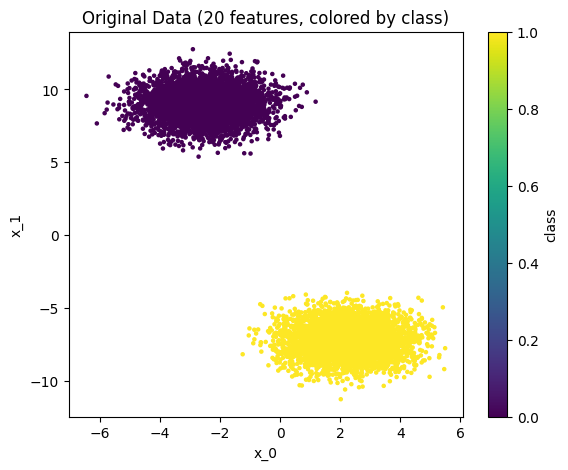

In [12]:
# Toy problem

n_features = 20
n_samples = 10000
n_classes = 2

x, y = make_blobs(n_samples=n_samples, n_features=n_features, random_state=42, shuffle=True, return_centers=False, centers=n_classes)
x_test, y_test = make_blobs(n_samples=int(n_samples / 2), n_features=n_features, random_state=42, shuffle=True, return_centers=False, centers=n_classes)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', s=5)
plt.xlabel('x_0')
plt.ylabel('x_1')   # <-- bonus fix: the original had plt.xlabel twice
plt.title('Original Data (20 features, colored by class)')
plt.colorbar(label='class')
plt.show()

#### 🧠 Inspect your data before modeling

Before you fit anything, get a feel for the dataset:

1. What is `x.shape`? `y.shape`?
2. The dataset has **20 features** but the plot only shows two (`x[:, 0]` vs `x[:, 1]`). What might be happening in the other 18 dimensions? Are they informative? Noisy? You don't know yet.
3. Use `np.unique(y, return_counts=True)` to check class balance. Are the two classes roughly equal in size? Why does that matter for training?

#### 🤖 Ask the agent
> *"I have a binary classification dataset with 20 features. Before training a model, what are 3–5 quick exploratory plots or statistics I should look at? Give me the code."*

#### 💬 Reflect
A lot of "the model doesn't work" turns out to be "the dataset is weird." Always look at your data first.

### 🐛 Three things to fix in the next cell

The cell below is **not ready to run**. We've left three things for you to fix — two are real bugs and one is just blanks for you to fill in.

**Before running, find:**
1. The two `??` placeholders. What numbers should they be? *Hint: look at the dataset shape you just printed.*
2. A typo in the class definition's parent class. (Look at how `nn.Module` was capitalized when you defined `SimpleNN` for regression — does it match here?)
3. The `super().__init__(self)` bug from before. Did you fix it in this cell too?

#### Try it yourself
Fix the cell *without* running the agent first. Run it. See if it works.

#### 🤖 If you get stuck
> *"This PyTorch class won't run. Here's the error: [paste]. Here's the class: [paste]. What needs to change?"*

#### 💬 Reflect
- How many of the three issues did you catch on your own before the agent told you?
- The first time you see an error like `AttributeError: module 'torch.nn' has no attribute 'module'` it looks cryptic. After you've seen it once, you'll spot it instantly. **Debugging is a learned skill, not innate.**

In [ ]:
# Defin the model, loss function, and optimizer for the classification problem

class SimpleNN(torch.nn.module):
    def __init__(self):
        super().__init__(self)

        self.input_layer = nn.Linear(??, 10) # <- same as before, but now the input layer has the number of input features as the dataset
        self.hidden_layer = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(10, ??) # <- output layer has to output the same number of classes as the dataset has

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x
    
model = SimpleNN()
criterion = nn.CrossEntropyLoss() #< - For classification problems, we typically use cross-entropy loss, which combines a softmax activation with a negative log likelihood loss.
optimizer = optim.Adam(model.parameters(), lr=0.001)

### ✍️ Now you write the training loop

The cell above defines the model, loss, and optimizer for the classification problem, but **you** have to write the training loop. Don't peek back at the regression training loop yet — try to write it from memory first.

#### Try it yourself

You will need to:
1. Convert `x`, `y` to PyTorch tensors. **Important:** for `CrossEntropyLoss`, the targets must be `torch.long` (integer class indices), not `torch.float32`. The inputs stay as `torch.float32`.
2. Wrap them in a `TensorDataset` and `DataLoader`.
3. Loop over epochs, then over batches, doing the five-step gradient-descent dance.
4. Track and print training loss per epoch.

(Bonus: also split off a validation set and track validation loss. You'll need this in Part 3 anyway.)

#### 🤖 Stuck? Try a *targeted* prompt
Bad prompt: *"write me the training loop"*
Good prompt: *"I have a PyTorch binary classification model with `CrossEntropyLoss`. My data is a NumPy array `x` of shape (10000, 20) and labels `y` of shape (10000,). Walk me through how to convert these to tensors (paying attention to dtypes for cross-entropy!) and write a basic training loop. Don't just give me code — explain each step."*

#### 💬 Reflect
- Did your loop work first try? If not, what was the bug?
- How does your validation accuracy compare to your training accuracy? If validation is much worse, what's going on? (Look up: *overfitting*.)

In [13]:
# Write training loop here

# Using DeepMerge Illustris - Using CNNS


## Why a *convolutional* network for images?

So far our networks have used `nn.Linear` (a.k.a. fully-connected or "dense") layers. Each output neuron is a weighted sum of *every* input. That's fine for 20-feature blobs.

But an image is different. A 100×100 RGB image has $100 \times 100 \times 3 = 30{,}000$ input features. A single fully-connected layer mapping that to even 64 hidden neurons would have $30{,}000 \times 64 \approx 2$ million parameters — and that's just *one* layer. Worse, it would learn that the pixel at position (47, 38) is meaningful in a way completely unrelated to the pixel at (48, 38), even though we know they're neighbors.

**Convolutional layers** solve both problems:

1. They use a small **kernel** (e.g. 3×3 or 5×5) that slides over the image, so the same weights are reused at every position. → way fewer parameters.
2. They learn **translation-equivariant** features. A galaxy looks like a galaxy whether it's in the top-left or bottom-right of the image.

### The DeepMerge dataset

We'll work with simulated images of galaxies from [DeepMerge](https://archive.stsci.edu/hlsp/deepmerge), an HST+JWST+NIRCam simulated dataset of galaxies at redshift z=2. Some are **mergers** (label 1), some are not (label 0). The challenge: train a CNN to tell them apart from the images alone.

This is the kind of task professional astronomers actually use neural networks for. The fundamental physics question — "are these two galaxies in the process of merging?" — would take a human expert minutes per image. A CNN can do millions per hour.

### 🧠 Before you load the data
Predict:
- How big is each image (pixels)?
- How many color channels? (Astronomy images often have channels per *wavelength filter*.)
- Roughly how many images total in the dataset?

You'll get answers in the next few cells. Write down your guesses first.

#### 🤖 Ask the agent (later, after running)
> *"Look up the DeepMerge dataset (Snyder et al. / Ćiprijanović et al.). What is the physical setup of the simulation, what are the labels, and what filters do the three image channels correspond to?"*

In [ ]:
version = 'pristine'
file_url = 'https://archive.stsci.edu/hlsps/deepmerge/hlsp_deepmerge_hst-jwst_acs-wfc3-nircam_illustris-z2_f814w-f160w-f356w_v1_sim-'+version+'.fits'
hdu = fits.open(download_file(file_url, cache=True, show_progress=True))

> ⏳ **Heads up:** the cell above downloads a multi-hundred-MB file the first time you run it. It's cached after that. If your kernel hangs, check your network and be patient.

In [ ]:
# select random image indices:
# Task: Create a NumPy array consisting of 16 random numbers ranging from 0 to len(hdu[1].data)
# Hint: Refer to the NumPy documentation to complete the line below


example_ids = np.random.choice(len(hdu[1].data),16)
#print(example_ids)

# pull the F160W image (index=1) from the simulated dataset for these selections

examples = [hdu[0].data[j,1,:,:] for j in example_ids]

# initialize your figure
fig1=plt.figure(figsize=(8,8))

# loop through the randomly selected images and plot with labels
for i, image in enumerate(examples):
    plt.subplot(4, 4, i + 1)
    plt.axis("off")

    norm = simple_norm(image, 'log')

    plt.imshow(image, aspect='auto', cmap='viridis', norm=norm)
    plt.title('Merger='+str(bool(hdu[1].data[example_ids[i]][0])))

plt.show()

#### 🔭 Look at the images!

This is **the most underrated step in machine learning**. Spend two full minutes actually looking at the plot above.

1. Can *you* tell which ones are mergers and which aren't? Cover up the titles and try.
2. What features of an image make a merger "obviously" a merger? Two distinct cores? Tidal tails? Asymmetry?
3. Are some non-mergers easy to mistake for mergers?

#### Try it yourself
Re-run the cell a few times (different `example_ids`) and form an intuition. Maybe even keep a tally: "I guessed right on 12 out of 16."

#### 💬 Reflect
- If *you* find this task hard, you should not be surprised when the CNN finds it hard too. The performance you can extract from a model is bounded above by the information actually present in the data.
- Conversely, if you discover an obvious visual cue, the CNN will probably find it within a few epochs of training.

In [ ]:
X = hdu[0].data #Images
y = hdu[1].data #Labels

X = np.asarray(X).astype('float32')
y = np.asarray(y).astype('float32')

# Task: Split the data into training and validation sets
# Hint: Look for the function train_test_split(???) in scikit-learn

# First split off 30% of the data for validation+testing
X_train, X_split, y_train, y_split = train_test_split(X, y, test_size=0.3,
                                        random_state=42, shuffle=True)

# Divide this subset into validation and testing sets in 1:2 ratio
X_val, X_test, y_val, y_test = train_test_split(X_split, y_split,
                                    test_size=2/3, random_state=42, shuffle=True)

imsize = np.shape(X_train)[2]

X_train = X_train.reshape(-1, imsize, imsize, 3)
X_valid = X_val.reshape(-1, imsize, imsize, 3)
X_test = X_test.reshape(-1, imsize, imsize, 3)

# And convert the data into PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Reserved for evalution on at the end
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### 🧠 Anatomy of a CNN

The cell below defines `GalaxyCNN`, a small but real convolutional network. It has **three "conv blocks"** followed by **three fully-connected layers**. Each conv block is the same recipe:

```
Conv2d  →  BatchNorm  →  ReLU  →  MaxPool  →  Dropout
```

Each of those does something specific:

- **`Conv2d`** — the convolution itself. Learns local features (edges, blobs, etc.).
- **`BatchNorm2d`** — normalizes activations across the batch. Helps training stability.
- **`ReLU`** — nonlinearity (same as before).
- **`MaxPool2d`** — downsamples the spatial dimensions by 2× (keeps the max in each 2×2 window). This is *how* the network builds up larger receptive fields.
- **`Dropout`** — randomly zeros out neurons during training. A regularization trick that prevents overfitting.

#### Try it yourself — before running
1. Trace the spatial dimensions. If the input image is `imsize × imsize`, what's the spatial size after conv block 1? After block 2? After block 3? (Remember: `padding='same'` keeps the conv output the same size; pooling halves it.)
2. Count the parameters of `self.conv1 = nn.Conv2d(3, 8, kernel_size=5, ...)`. Formula: `(kernel_size² × in_channels × out_channels) + out_channels` (the `+out_channels` is for biases).
3. Why does `flattened_size = 32 * (imsize // 8) * (imsize // 8)` use `// 8`? (Hint: three poolings of factor 2.)

#### 🤖 Ask the agent
> *"Walk me through the spatial dimensions of activations as they flow through this CNN, assuming a 75×75 input image. [paste code]. For each layer, tell me the output shape (channels × height × width)."*

#### 💬 Reflect
Reading a CNN architecture and being able to picture what the tensors look like at each step is a key skill. Practice on every CNN you see.

In [ ]:
# Building a convolusional neural network (CNN) in PyTorch

class GalaxyCNN(nn.Module):
    def __init__(self, imsize):
        super().__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv2d(3, 8, kernel_size=5, stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=None)
        self.dropout1 = nn.Dropout(0.5)
        
        # Conv block 2
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=None)
        self.dropout2 = nn.Dropout(0.5)
        
        # Conv block 3
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding='same')
        self.bn3 = nn.BatchNorm2d(32)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=None)
        self.dropout3 = nn.Dropout(0.5)
        
        # Fully connected layers
        # Calculate flattened size after 3 pooling layers (each halves spatial dims)
        flattened_size = 32 * (imsize // 8) * (imsize // 8)
        
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Conv block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Conv block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Conv block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Flatten
        x = torch.flatten(x, 1)
        
        # Fully connected layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        
        return x

# Create model instance (assuming imsize is defined from your data)
model = GalaxyCNN(imsize)
summary(model, input_size=(1, 3, imsize, imsize))


### ✍️ Now build the CNN training loop

The next three cells set up the loss function (missing — you write it), give you a `history` dict to populate, and leave you a blank space for the training loop. This is the **biggest exercise of the notebook**. Block out 30–60 minutes for it.

#### Try it yourself first

Your loop should:
1. Pick a loss function appropriate for **binary classification with sigmoid output**. (Look at `GalaxyCNN.forward` — it ends with `self.sigmoid(x)`. Which PyTorch loss function pairs with that? It is **not** `CrossEntropyLoss`.)
2. Pick an optimizer (Adam is a fine default).
3. Loop over epochs and batches.
4. After each epoch, populate `history['loss']`, `history['val_loss']`, `history['accuracy']`, `history['val_accuracy']`.
5. Print progress.

Things you'll need to think about:
- The image data was reshaped to `(N, H, W, 3)` but PyTorch conv layers expect `(N, 3, H, W)`. You'll need to permute! Look up `tensor.permute(...)`.
- The labels `y_train` are shape `(N,)` but the model outputs shape `(N, 1)`. You may need to reshape one of them.
- `accuracy_score` from sklearn expects integer class predictions, not probabilities. You'll need to threshold the sigmoid output at 0.5.

#### 🤖 When to ping the agent
Don't ask it to write the whole loop. Instead, ask targeted questions as they come up:

- *"My input tensor is shape `(N, 75, 75, 3)` but `nn.Conv2d` is complaining. How do I rearrange the axes in PyTorch?"*
- *"My binary classification model outputs a sigmoid probability. What's the right PyTorch loss function and what shape should my labels be?"*
- *"How do I compute accuracy in PyTorch when my model outputs a sigmoid probability between 0 and 1?"*

#### 💬 Reflect
- How many small bugs did you hit before it worked? Each one is a future debugging skill.
- How long does one epoch take on your machine? If it's painfully slow, look up `torch.device('cuda')` and GPU acceleration.
- What did your final training and validation accuracy look like? Are they close? If validation lags badly, you're overfitting.

In [ ]:
# We need two main things here - a loss function and the optimizer
# The optimizer is a hyperparameter that doesn't need to be changed based on archecture or task, 
# But the loss function is different for classification and regression. 
# A classification loss needed to be able to accept the output of the model (probablity), and the true labels (0, 1)

# Different losses are listed here https://docs.pytorch.org/docs/2.11/nn.html#loss-functions

# The process of training the model looks pretty similar as before, so I won't write out out
# Try to use the example of the training loop we had before, but now with the new model and loss function.

# You will need to track the training and validation loss

In [ ]:
history = {
    "loss" : [], # <- Loss reported by the model
    "val_loss" : [], 
    "accuracy" : [], # <- Accuracy given by sklearn.metrics.accuracy_score
    "val_accuracy" : [] 
} # track these during the training loop

In [ ]:
# Write the training and validation loops


In [ ]:
# plotting from history

loss = history['loss']
val_loss = history['val_loss']
acc = history['accuracy']
val_acc = history['val_accuracy']

epochs = list(range(len(loss)))
figsize=(6,4)
fig, axis1 = plt.subplots(figsize=figsize)
plot1_lacc = axis1.plot(epochs, acc, 'navy', label='accuracy')
plot1_val_lacc = axis1.plot(epochs, val_acc, 'deepskyblue', label="validation accuracy")

plot1_loss = axis1.plot(epochs, loss, 'red', label='loss')
plot1_val_loss = axis1.plot(epochs, val_loss, 'lightsalmon', label="validation loss")


plots = plot1_loss + plot1_val_loss
labs = [l.get_label() for l in plots]
axis1.set_xlabel('Epoch')
axis1.set_ylabel('Loss/Accuracy')
plt.title("Loss/Accuracy History (Pristine Images)")
plt.tight_layout()
axis1.legend(loc='lower right')

### 🐛 Another teachable bug coming up

The next cell runs your trained model on the test set. It looks innocent, but a few things may go wrong when you actually try to evaluate accuracy / confusion matrix / ROC:

1. `test_outputs` will be **sigmoid probabilities** (floats between 0 and 1), but `confusion_matrix` expects **integer class predictions** (0 or 1). You'll need to threshold somewhere.
2. The same applies for `accuracy_score`.
3. `roc_curve` and `roc_auc_score`, on the other hand, want the **continuous score**, not the thresholded prediction. So you need *both* versions.

#### Try it yourself
Before running the next batch of evaluation cells, plan: where in your code will you compute (a) the thresholded predictions for confusion matrix / accuracy, and (b) keep the raw probabilities for the ROC curve?

#### 🤖 Ask the agent
> *"For a binary classifier that outputs a sigmoid probability, I want to compute (a) accuracy, (b) confusion matrix, and (c) ROC AUC. Which of these need thresholded predictions and which need raw probabilities? Show me the cleanest way to compute all three."*

#### 💬 Reflect
This distinction — *score* vs *prediction* — is something many beginners get wrong. The ROC curve is literally the function that says "if I threshold at every possible value, here are my TPR/FPR pairs." It needs the raw score to do that.

In [ ]:
# Now we need to evaluate the trained model on test data
with torch.no_grad(): # Disable gradient calculation for testing, as we aren't updating the parameters of the model with the test data
    test_outputs = model(X_test) # Pass the test data through the model to get predictions
    test_loss = criterion(test_outputs, y_test) # Calculate the loss between the predictions and the true values
print(f"Test Loss: {test_loss.item():.4f}") # Report the test loss

# We can also check a lot of different types of metrics, which all tell us different things about the performance

## Confusion Matrix 

A good option for visualizing the goodness of the predictions is the confusion matrix.

It shows the counts of True Positives (TP), False Positives (FP), True Negatives (TN), and False Negatives (FN).

A perfect classifier would have all predictions along the diagonal (top-left to bottom-right), indicating correct classifications. However, confusion matrices for real-world classifiers may have varied distributions across these categories leading to off-diagonal values.

Understanding the confusion matrix helps in assessing the model's strengths and weaknesses, particularly in identifying where it tends to misclassify instances.

In [ ]:
# measure confusion
labels=[0, 1]
cm = confusion_matrix(y_test, test_outputs, labels=labels)
cm = cm.astype('float') # regular CM
cm_norm = cm / cm.sum(axis=1)[:, np.newaxis] # normalized CM


#plotting
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix', y=1.08)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
fmt = '.0f'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
        ha="center", va="center",
        color="white" if cm[i, j] < thresh else "black")
plt.show()

#### 🧠 Read the confusion matrix like a physicist

Suppose your confusion matrix looks like this (made up numbers):

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **True 0** | 420 | 80 |
| **True 1** | 60 | 440 |

Answer:
1. What is the overall accuracy?
2. What is the **precision** for class 1 (mergers)? (Of all things predicted as mergers, how many were truly mergers?)
3. What is the **recall** for class 1? (Of all true mergers, how many did we catch?)
4. In an astronomy survey where mergers are *rare* (say 1 in 1000 galaxies), which is more important to optimize — precision or recall? Why?

#### 🤖 Ask the agent
> *"Define precision, recall, and F1 score in terms of TP/FP/TN/FN. Then explain in one paragraph when I should care more about precision vs recall, with a physics or astronomy example."*

#### 💬 Discuss
"Accuracy" can be misleading when classes are imbalanced. If 99% of galaxies are *not* mergers, a model that says "not a merger" to every image gets 99% accuracy and is completely useless. This is why precision, recall, F1, and ROC AUC exist — they tell you something more informative.

# ROC Curve

Another common plot is the Receiver Operating Characteristic (ROC) plot.

It shows the trade-off between TP and FP.

A perfect cassifier has a curve that approaches top left corner, while a classifier that randomly predicts labels has ROC curve close to the diagonal.

Calculating the Area under the ROC curve (AUC) is a good indicator of performance (we aim to be close to AUC = 1).

Read more about the ROC curve and AUC [here](https://keras.rstudio.com/reference/metric_auc.html).

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, test_outputs, pos_label=1)
auc = roc_auc_score(y_test, test_outputs)


figsize=(5,5)
fig, axis1 = plt.subplots(figsize=figsize)
x_onetoone = y_onetoone = [0, 1]
plt.plot(fpr, tpr, 'r-')
plt.plot(x_onetoone, y_onetoone, 'k--',  label="1-1")
plt.legend(loc=0)
plt.title("Receiver Operator Characteristic (ROC)")
plt.xlabel("False Positive (1 - Specificity)")
plt.ylabel("True Positive (Selectivity)")
#Adding text inside a rectangular box by using the keyword 'bbox'
plt.text(0.5, 0.2, "AUC ="+"{0:.2f}".format(auc), fontsize = 22,
         bbox = dict(facecolor = 'red', alpha = 0.5))
plt.tight_layout()

---

# Wrap-up: what you've actually learned

Stop here and write down (genuinely, in a markdown cell below or on paper) the answers to these:

1. **The training loop.** Can you, from memory, write the five lines inside the inner batch loop? (zero_grad, forward, loss, backward, step.)
2. **Regression vs classification.** What changes when you switch from one to the other? (Output size, final activation, loss function.)
3. **Dense vs convolutional.** Why are CNNs preferred for images? Give two reasons.
4. **Three sets.** What's the difference between train, validation, and test? What goes wrong if you tune on the test set?
5. **Extrapolation.** Why couldn't your $y=x^2$ network predict well outside the training range?

### 🤖 Final agent exercise: have the agent quiz *you*

Try this prompt with your agent:

> *"I just finished a notebook on PyTorch neural networks covering regression (predicting y=x²), classification (a blobs dataset), and a CNN (galaxy merger classification with the DeepMerge dataset). Quiz me with 5 conceptual questions of increasing difficulty. Ask one at a time, wait for my answer, and only then tell me if I'm right and explain."*

This flips the relationship. You're not asking the agent for information — you're using it to **test what you actually retained**.

### 💬 Final reflection: what should you (not) trust the agent for?

By now you've probably noticed:

- The agent is **great** at: explaining standard concepts, debugging error messages, suggesting cleaner code, summarizing documentation.
- The agent is **mediocre** at: choosing the right loss for your specific dataset (it'll guess based on what's common), counting parameters precisely (it might get tensor shapes wrong), telling you when your data is the actual problem.
- The agent is **bad** at: knowing the latest version of a library, knowing your specific data, telling you when your scientific question itself is the issue.

The big takeaway for the rest of this course — and for your career — is this:

> An agent is an enormously powerful assistant for someone who already understands the basics. It is a treacherous crutch for someone who doesn't. **The point of doing the exercises by hand first is so you can tell when the agent is lying.**

Good luck with the rest of the Summer!


# Additional Homework Problem

###  A real(ish) physics regression

Pick **one** of the following and build a regressor for it using what you just learned. The data generator code is short — write it yourself.

1. **Projectile range.** Given launch speed $v$ and angle $\theta$, predict range $R = v^2 \sin(2\theta)/g$. Generate a few thousand samples with $v \in [10, 50]$ m/s and $\theta \in [10°, 80°]$. Two inputs, one output.
2. **Pendulum period.** Given length $L$ and amplitude $\theta_0$, predict period $T$ (use the leading correction $T \approx 2\pi\sqrt{L/g}\,(1 + \theta_0^2/16)$ for small but not-tiny angles).
3. **Coulomb force magnitude.** Given $q_1, q_2, r$, predict $F$.

#### Workflow
1. **Try yourself first.** Write the data generator, copy-modify the `SimpleNN` class (you'll need to change the input size), and train it.
2. **Then** ask the agent for help if you're stuck on a specific point — but be specific. "It doesn't work" is a bad prompt; "my loss is `nan` after epoch 3" is a great one.
3. After training, plot predictions vs. truth and report the test MSE.

#### 💬 Discuss
- Which task was easiest for the network? Hardest? Why might that be?
- Did anyone need to **normalize the inputs** (e.g. divide $v$ by its max)? What happens if you don't?